---
title: "Homework 2 Answers Kaggle Competition: Predicting Irrigation Need"
author: Karisa Kopecek
date: today
format:
  html:
    embed-resources: true
    echo: true
---

### Disclaimer: I was forced to change the catboost model in order to make it run fast enough. I can see that deeper and more time consuming tuning would be helpful and make the model preform better (specifically more iterations and n_trials). However, the benefit to more iterations I felt would be very tiny, but the extra time it was taking me was exponential (ran model for 2 hours and then decided it had to be simpler, then ran for 40 mins, then still had to make simpler).

## Model's and Methodology

Catboost link: https://github.com/karisamarykopecek/Kaggle_Comp_Irrigation/blob/main/CatBoost_NewFeatures.ipynb

Ensemble link: https://github.com/karisamarykopecek/Kaggle_Comp_Irrigation/blob/main/Ensemble_Stacking.ipynb

## Questions 

### Discuss your approaches.

I saw that in the instructions you asked for us to try new models that haven't been tried a lot. I have not yet really investigated catboost. Also, since I knew I would be doing ensembling later, I felt this model might work well. I also knew you wanted us to look at more feature engineering. So, I first made a model with catboost and a lot more feature engineering. Unfortunatly, in my previous models I was using balanced F1 score (I chose to swtich to a new scoring method for this assignment to better match how the kaggle score itself works). So, comparing old models is a little difficult, but overall I saw that a few of my engineered features ended up doing well. CatBoost itself I was still iffy about, but then I made an ensemble modeling document with XGBoost, LightGBM, and CatBoost. I used out-of-fold predictions and tested two ensemble methods: soft probability averaging (equal and score-proportional weights) and stacking with a meta-model. The stacking model preformed great! 

### What did you try? 

**CatBoost_NewFeatures:**

Introduced CatBoost as a new model type that handles categorical strings internally and builds symmetric trees (structurally different from XGBoost and LightGBM). 

Added 6 new features across three approaches: interaction (region_season, crop_water_source), transformation (sunlight_heat_load, rainfall_per_sunlight), and grouping (soil_type_mean_moisture, moisture_gap)

Tuned with 3 manual configs then did Optuna trials scored by balanced accuracy

Evaluated which features actually mattered using SHAP values, with new vs. old features highlighted separately

**Ensemble_Stacking:**

Combined XGBoost, LightGBM, and CatBoost using out-of-fold predictions so each model predicts only on rows it never trained on.

Tested two ensemble methods: soft probability averaging (equal and score-proportional weights) and stacking with a meta-model

Ran Optuna independently for each base model within the notebook 

Compared all six approaches (3 solo models + 2 averaging variants + stacking) on the same OOF data to evaluate whether combining models beat any individual one
 
### What worked well? 

CatBoost performed even better than my old XGBoost model! I'm glad I included it even after it ran for a long time. The six new features contributed positively based on SHAP values, with the interaction features (region_season, crop_water_source) showing up in the top rankings alongside the previously engineered ones (plus a lot of the original features themselves, which I did expect). The ensemble improved over individual models, which validated that the three models were making at least partially different mistakes and combining them helped. I learned that choosing the right models and different models is very important for ensembling (at least from what I have seen).

### What didn't work well? 

CatBoost runtime was the biggest practical problem throughout both notebooks (it ran far longer than expected and required significant tuning of trial counts, iteration ceilings, and sample sizes just to finish in a reasonable time). I wasn't happy with not being able to get as deep of info as I wanted because it was taking so long. The OOF generation loop was also very slow. In some cases I had to limit how much data was being fed into things, which will affect preformance of the models. 

### What will you continue to use moving forward? 

The full feature set including all six new engineered features since they held up under SHAP evaluation. The ensemble approach since it improved over solo models. Optuna tuning with a capped sample size (20K) for slow models like CatBoost. The OOF-based stacking structure since it gives honest performance estimates without overfitting. Everything I tried in this case, even though it was long, resulted in improved scoring. 

### Were model improvements meaningful or small? 

Small but consistent. Individual model scores were all close together, and the ensemble gained a small additional increment on top of that. In this case, because the top scores on kaggle are also close together, I still think this ensemble preformance is a meaningful value just because I am getting to kinda the top 1000 ish scores on kaggle (there might be ceiling on how well I can do given I can't run the model for days and days).

### Summary Table of Results 

| Model | Family | CV Weighted F1 | Leaderboard |
|---|---|---|---|
| XGBoost Config A (Deep + Reg + min_child) | Boosting | 0.9821 (sd 0.0004) | - |
| XGBoost Config B (Leaf-wise Growth) | Boosting | 0.9822 (sd 0.0005) | - |
| XGBoost Config C (Deeper + Aggressive Subsample) | Boosting | 0.9820 (sd 0.0005) | - |
| XGBoost Config D (Optuna) | Boosting | 0.9822 (sd 0.0008) | 0.96419 |
| LightGBM Config A (Few Leaves/High LR) | Boosting | 0.9814 (sd 0.0006) | - |
| LightGBM Config B (Deeper + Aggressive Subsample) | Boosting | 0.9815 (sd 0.0005) | - |
| LightGBM Config C (Explicit Regularization) | Boosting | 0.9810 (sd 0.0003) | - |
| LightGBM Config D (Optuna) | Boosting | - | 0.96380 |

| Model | Family | CV Balanced Accuracy | Leaderboard |
|---|---|---|---|
| CatBoost Config A (Moderate Depth, Slow LR) | Boosting | 0.9587 (sd 0.0037) | - |
| CatBoost Config B (Shallow Trees, High LR) | Boosting | 0.9558 (sd 0.0014) | - |
| CatBoost Config C (Deeper Trees, Strong L2) | Boosting | 0.9585 (sd 0.0042) | - |
| CatBoost Config D (Optuna) | Boosting | 0.9607 (sd 0.0033) | 0.96696 |
| XGBoost (Ensemble Optuna) | Boosting | 0.9574 (OOF: 0.9678) | - |
| LightGBM (Ensemble Optuna) | Boosting | 0.9518 (OOF: 0.9669) | - |
| CatBoost (Ensemble Optuna) | Boosting | 0.9601 (OOF: 0.9681) | - |
| Avg Equal Weights | Ensemble | OOF: 0.9682 | - |
| Avg Score Weights | Ensemble | OOF: 0.9682 | - |
| Stacking (XGB + LGB + CatBoost) | Ensemble | OOF: 0.9703 | 0.96905 |


### Kaggle Score Updated (the ensemble did best, I just happened to upload catboost alone after it which did worse)


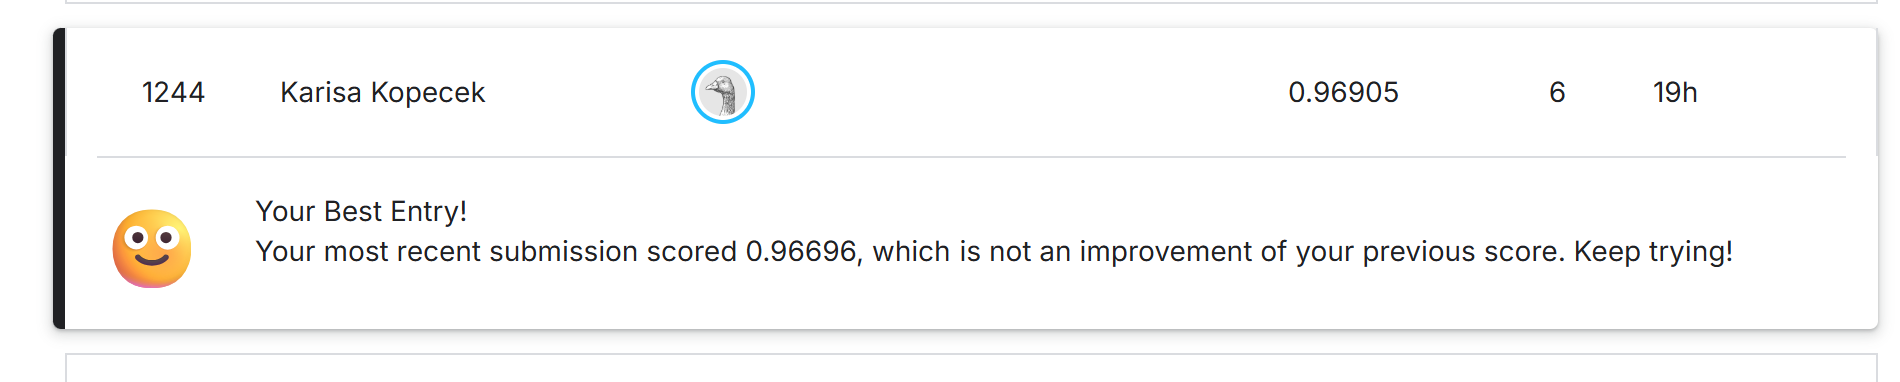

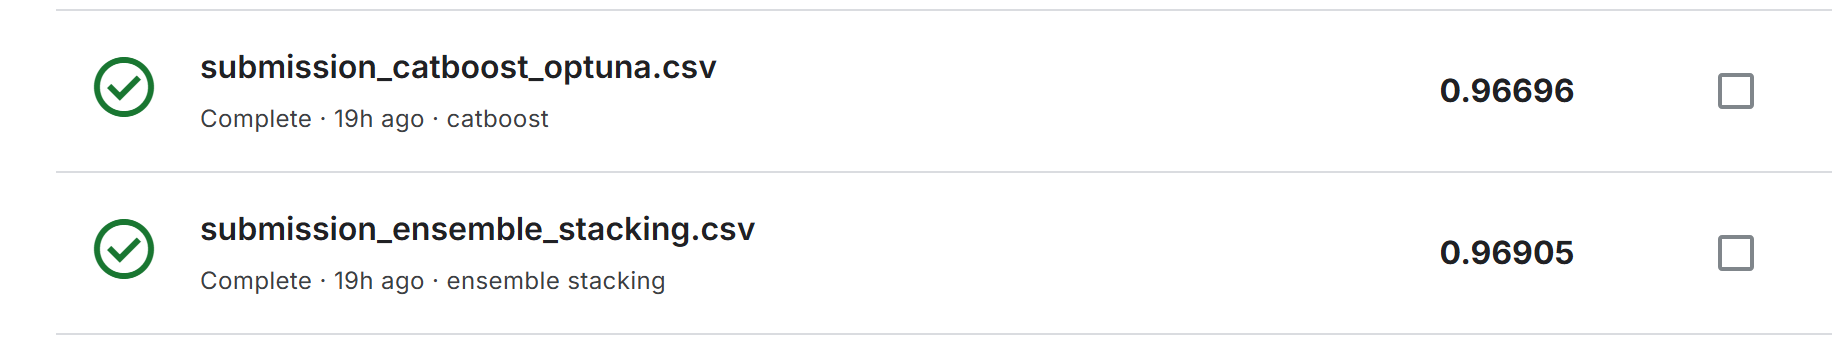